In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score


In [ ]:
PATH_DRIVE = '/content/drive/MyDrive/Eafit/TDG/Codigo/Final/'
low_elo = PATH_DRIVE + "matches_low_elo.csv"
high_elo = PATH_DRIVE + "matches_high_elo.csv"
capa_gold = PATH_DRIVE + "capa_gold_final.csv"
win_rate = PATH_DRIVE + "winrate.xlsx"
print(f"Ruta de dataset: {low_elo}")
print(f"Ruta de dataset: {high_elo}")
print(f"Ruta de capa Gold: {capa_gold}")
print(f"Ruta de Win Rate: {win_rate}")

Ruta de dataset: /content/drive/MyDrive/Eafit/TDG/Codigo/Final/matches_low_elo.csv
Ruta de dataset: /content/drive/MyDrive/Eafit/TDG/Codigo/Final/matches_high_elo.csv
Ruta de capa Gold: /content/drive/MyDrive/Eafit/TDG/Codigo/Final/capa_gold_final.csv
Ruta de Win Rate: /content/drive/MyDrive/Eafit/TDG/Codigo/Final/winrate.xlsx


In [ ]:
df_low_elo = pd.read_csv(low_elo)
df_high_elo = pd.read_csv(high_elo)
df_capa_gold = pd.read_csv(capa_gold)
df_win_rate = pd.read_excel(win_rate)

print(f"Filas en matches_low_elo.csv: {df_low_elo.shape[0]}")
print(f"Filas en matches_high_elo.csv: {df_high_elo.shape[0]}")
print(f"Filas en capa_gold_final.csv: {df_capa_gold.shape[0]}")
print(f"Filas en winrate.xlsx: {df_win_rate.shape[0]}")

Filas en matches_low_elo.csv: 16650
Filas en matches_high_elo.csv: 13550
Filas en capa_gold_final.csv: 172
Filas en winrate.xlsx: 172


In [ ]:
n_rows_high_elo = df_high_elo.shape[0]
df_low_elo = df_low_elo.sample(n=n_rows_high_elo, random_state=42)


print(f"Filas de df_high_elo: {df_high_elo.shape[0]}")
print(f"Filas de df_low_elo (después de muestreo): {df_low_elo.shape[0]}")

Filas de df_high_elo: 13550
Filas de df_low_elo (después de muestreo): 13550


In [ ]:
def clean_ids(df, columns):
    for col in columns:
        # Eliminamos filas con NaNs en IDs para que no falle el astype
        df = df.dropna(subset=[col])
        df[col] = df[col].astype(int).astype(str)
    return df

# IDs en las partidas (b1..b5, r1..r5)
match_cols = [f'b{i}' for i in range(1, 6)] + [f'r{i}' for i in range(1, 6)]
df_low_elo = clean_ids(df_low_elo, match_cols)
df_high_elo = clean_ids(df_high_elo, match_cols)

# IDs en las tablas de referencia
df_capa_gold = clean_ids(df_capa_gold, ['id'])
df_win_rate = clean_ids(df_win_rate, ['id'])

# --- LIMPIEZA DE COLUMNAS ---
# Quitamos espacios en blanco invisibles en los nombres de las columnas
df_capa_gold.columns = df_capa_gold.columns.str.strip()
df_win_rate.columns = df_win_rate.columns.str.strip()

# Impresión de control
print(f"✅ Filas en matches_low_elo: {df_low_elo.shape[0]}")
print(f"✅ Filas en matches_high_elo: {df_high_elo.shape[0]}")
print(f"✅ Campeones en Capa Gold: {df_capa_gold.shape[0]}")
print(f"✅ Campeones en Win Rate Excel: {df_win_rate.shape[0]}")

✅ Filas en matches_low_elo: 13550
✅ Filas en matches_high_elo: 13550
✅ Campeones en Capa Gold: 172
✅ Campeones en Win Rate Excel: 172


In [ ]:
# 1. Definimos los nombres de tus columnas en el Excel (Ajústalos si se llaman distinto)
col_wr_apex = 'WinRate_hig_elo'
col_wr_low = 'WinRate_low_elo'

# reamos los diccionarios específicos
# Limpiamos NaNs para evitar errores matemáticos
df_wr_clean = df_win_rate.dropna(subset=[col_wr_apex, col_wr_low]).copy()

wr_apex_dict = dict(zip(df_wr_clean['id'].astype(str), df_wr_clean[col_wr_apex].astype(float)))
wr_low_dict = dict(zip(df_wr_clean['id'].astype(str), df_wr_clean[col_wr_low].astype(float)))

# Mapa de Win Rates para el bucle automático
wr_maps = {
    'Apex': wr_apex_dict,
    'LowTier': wr_low_dict
}

print(f"✅ Diccionario Apex cargado con {len(wr_apex_dict)} campeones.")
print(f"✅ Diccionario LowTier cargado con {len(wr_low_dict)} campeones.")

✅ Diccionario Apex cargado con 172 campeones.
✅ Diccionario LowTier cargado con 172 campeones.


In [ ]:
# 2. Definición de nombres de columnas
stats_features = ['Gold_Phys_Dmg', 'Gold_Mag_Dmg', 'Gold_DPS', 'Gold_Durability',
                  'Gold_CC', 'Gold_Poke', 'Gold_Engage', 'Gold_Utility', 'Gold_Kiting']

official_classes = ['Juggernaut', 'Burst', 'Assassin', 'Marksman', 'Vanguard',
                    'Diver', 'Battlemage', 'Specialist', 'Catcher', 'Skirmisher',
                    'Warden', 'Artillery', 'Enchanter']

stats_cols = [f'delta_{s}' for s in stats_features]
class_cols = [f'delta_cnt_{c}' for c in official_classes]
eng_cols = ['ratio_lethality', 'ratio_spacing', 'ratio_cc_density']

In [ ]:
def get_stage_data(df_raw, stage, current_wr_dict):
    X_list, y_list = [], []
    skipped_matches_count = 0

    for idx, row in df_raw.iterrows():
        # Extraemos IDs de Blue y Red
        b_ids = [str(int(row[f'b{i}'])) for i in range(1, 6)]
        r_ids = [str(int(row[f'r{i}'])) for i in range(1, 6)]

        # Validación de integridad usando el diccionario del TIER actual
        all_champs_found = True
        for c_id in b_ids + r_ids:
            # Ahora validamos contra 'current_wr_dict', que será Apex o Low según toque
            if c_id not in current_wr_dict or c_id not in champ_vectors_by_id:
                all_champs_found = False
                break

        if all_champs_found:
            # A. Cálculos de Win Rate (Usando la brújula correcta)
            d_wr = np.mean([current_wr_dict[c] for c in b_ids]) - np.mean([current_wr_dict[c] for c in r_ids])

            # B. Cálculos de Stats y Clases (Vectores Capa Gold)
            b_v = np.sum([champ_vectors_by_id[c] for c in b_ids], axis=0)
            r_v = np.sum([champ_vectors_by_id[c] for c in r_ids], axis=0)
            deltas_22 = list(b_v - r_v)

            # C. Feature Engineering (Ratios de Capa Gold)
            # Ratios: 0:Phys_Dmg/3:Durability, 5:Poke/6:Engage, 4:CC/2:DPS
            ratios = [
                (b_v[0]/(r_v[3]+1)) - (r_v[0]/(b_v[3]+1)),
                (b_v[5]/(r_v[6]+1)) - (r_v[5]/(b_v[6]+1)),
                (b_v[4]/(r_v[2]+1)) - (r_v[4]/(b_v[2]+1))
            ]

            # D. Asignación de Etapa (Complejidad incremental)
            if stage == 1:
                f = [d_wr]
            elif stage == 2:
                f = deltas_22
            elif stage == 3:
                f = deltas_22 + ratios
            elif stage == 4:
                f = [d_wr] + deltas_22 + ratios

            # E. Simetrización (Data Augmentation)
            X_list.append(f)
            y_list.append(row['win'])

            X_list.append([-val for val in f])
            y_list.append(1 - row['win'])

        else:
            skipped_matches_count += 1

    if skipped_matches_count > 0:
        print(f"Skipped {skipped_matches_count} matches in current df_raw (out of {len(df_raw)}) due to missing champion data.")

    return np.array(X_list), np.array(y_list)

In [ ]:
# 3. Creación del diccionario de vectores (Binarización de clases)
def build_champ_vectors(df):
    vectors = {}
    for _, row in df.iterrows():
        # A. Extraer las 9 estadísticas Gold
        stats_part = [float(row[stat]) for stat in stats_features]

        # B. Binarizar clases (buscamos en class_1 y class_2)
        class_part = [0] * len(official_classes)
        c1 = str(row['class_1']).strip()
        c2 = str(row['class_2']).strip() if pd.notna(row['class_2']) else ""

        for i, cls_name in enumerate(official_classes):
            if c1 == cls_name or c2 == cls_name:
                class_part[i] = 1

        # C. Unificar en vector de 22 dimensiones
        full_vector = np.array(stats_part + class_part)
        vectors[str(int(row['id']))] = full_vector
    return vectors

# Generamos el diccionario maestro de vectores
champ_vectors_by_id = build_champ_vectors(df_capa_gold)

# Control de calidad
# Actualiza esta parte para que veas ambos diccionarios cargados
print(f"✅ Diccionario WinRate Apex: {len(wr_apex_dict)} campeones.")
print(f"✅ Diccionario WinRate LowTier: {len(wr_low_dict)} campeones.")
print(f"✅ Diccionario Vectores (Capa Gold): {len(champ_vectors_by_id)} campeones.")

✅ Diccionario WinRate Apex: 172 campeones.
✅ Diccionario WinRate LowTier: 172 campeones.
✅ Diccionario Vectores (Capa Gold): 172 campeones.


In [ ]:
# --- 3. BUCLE DE COMPETENCIA (Sincronizado con Doble Win Rate) ---
results_list = []
tiers = [('Apex', df_high_elo), ('LowTier', df_low_elo)]

# Mapeo de diccionarios para que el bucle sepa cuál usar
wr_maps = {
    'Apex': wr_apex_dict,
    'LowTier': wr_low_dict
}


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 1. Definición de las Grillas de Parámetros (Ajustadas para no tardar una eternidad)
param_grids = {
    'Logistic': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__penalty': ['l2']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, 15],
        'model__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'model__n_estimators': [200, 300],
        'model__learning_rate': [0.01, 0.05],
        'model__max_depth': [3, 5]
    },
    'LightGBM': {
        'model__n_estimators': [200, 300],
        'model__learning_rate': [0.01, 0.05],
        'model__max_depth': [3, 5]
    },
    'NeuralNet': {
        'model__hidden_layer_sizes': [(64,), (64, 32)],
        'model__alpha': [0.001, 0.01]
    }
}

# 2. Diccionario de Modelos Base
base_models = {
    'Logistic': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(verbose=-1, random_state=42),
    'NeuralNet': MLPClassifier(max_iter=1000, random_state=42)
}

results_list = []

for t_name, t_df in tiers:
    current_wr_map = wr_maps[t_name]

    # Mantenemos el Split Blindado para una evaluación final totalmente independiente
    train_raw, test_raw = train_test_split(t_df, test_size=0.2, random_state=42)

    for stage in range(1, 5):
        print(f"\n🚀 Iniciando Optimización: {t_name} - Etapa {stage}")
        X_train, y_train = get_stage_data(train_raw, stage, current_wr_map)
        X_test, y_test = get_stage_data(test_raw, stage, current_wr_map)

        for m_name, model_obj in base_models.items():
            print(f"   🔎 Buscando mejor {m_name}...")

            # Creamos un Pipeline: Escala los datos y luego entrena
            # Esto es vital para CV para que el escalado sea 'limpio' por cada fold
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', model_obj)
            ])

            # Configuramos GridSearchCV (3-fold CV para balancear rigor y velocidad)
            grid = GridSearchCV(
                pipe,
                param_grids[m_name],
                cv=3,
                scoring='roc_auc',
                n_jobs=-1 # Usa todos los núcleos de tu CPU
            )

            grid.fit(X_train, y_train)

            # Evaluación final en el set de TEST (datos que el Grid nunca vio)
            best_model = grid.best_estimator_
            p_class = best_model.predict(X_test)
            p_prob = best_model.predict_proba(X_test)[:, 1]

            results_list.append({
                'Tier': t_name,
                'Etapa': stage,
                'Modelo': m_name,
                'Best_Params': grid.best_params_,
                'CV_Mean_AUC': grid.best_score_, # El AUC promedio en el entrenamiento
                'Test_Acc': accuracy_score(y_test, p_class),
                'Test_AUC': roc_auc_score(y_test, p_prob),
                'Test_F1': f1_score(y_test, p_class)
            })

df_grid_results = pd.DataFrame(results_list)
print("\n✅ ¡GridSearch y Cross-Validation completados!")


🚀 Iniciando Optimización: Apex - Etapa 1
   🔎 Buscando mejor Logistic...
   🔎 Buscando mejor RandomForest...
   🔎 Buscando mejor XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:57:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   🔎 Buscando mejor LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   🔎 Buscando mejor NeuralNet...

🚀 Iniciando Optimización: Apex - Etapa 2
   🔎 Buscando mejor Logistic...
   🔎 Buscando mejor RandomForest...
   🔎 Buscando mejor XGBoost...


...

   🔎 Buscando mejor NeuralNet...

🚀 Iniciando Optimización: LowTier - Etapa 4
   🔎 Buscando mejor Logistic...
   🔎 Buscando mejor RandomForest...
   🔎 Buscando mejor XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:44:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   🔎 Buscando mejor LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   🔎 Buscando mejor NeuralNet...

✅ ¡GridSearch y Cross-Validation completados!


In [ ]:
df_grid_results.sort_values(by='Test_AUC', ascending=False)

,Tier,Etapa,Modelo,Best_Params,CV_Mean_AUC,Test_Acc,Test_AUC,Test_F1
37,LowTier,4,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.560413,0.556458,0.566589,0.557926
38,LowTier,4,LightGBM,"{'model__learning_rate': 0.01, 'model__max_dep...",0.560183,0.555535,0.565894,0.555617
22,LowTier,1,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.557944,0.544465,0.565861,0.573501
20,LowTier,1,Logistic,"{'model__C': 0.01, 'model__penalty': 'l2'}",0.560242,0.553137,0.565630,0.553137
24,LowTier,1,NeuralNet,"{'model__alpha': 0.01, 'model__hidden_layer_si...",0.560243,0.551476,0.565630,0.574330
21,LowTier,1,RandomForest,"{'model__max_depth': 5, 'model__min_samples_sp...",0.555627,0.544096,0.565601,0.556771
23,LowTier,1,LightGBM,"{'model__learning_rate': 0.01, 'model__max_dep...",0.558159,0.546310,0.564998,0.596951
35,LowTier,4,Logistic,"{'model__C': 0.01, 'model__penalty': 'l2'}",0.561214,0.545387,0.560960,0.545387
36,LowTier,4,RandomForest,"{'model__max_depth': 5, 'model__min_samples_sp...",0.556058,0.557565,0.559699,0.555926
2,Apex,1,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.535246,0.545203,0.556275,0.540026


In [ ]:
# --- NUEVO: Diccionario para guardar los modelos físicos ---
best_models_storage = {}

for t_name, t_df in tiers:
    current_wr_map = wr_maps[t_name]
    train_raw, test_raw = train_test_split(t_df, test_size=0.2, random_state=42)

    for stage in range(1, 5):
        print(f"\n🚀 Optimización: {t_name} - Etapa {stage}")
        X_train, y_train = get_stage_data(train_raw, stage, current_wr_map)
        X_test, y_test = get_stage_data(test_raw, stage, current_wr_map)

        for m_name, model_obj in base_models.items():
            print(f"   🔎 Buscando {m_name}...")

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', model_obj)
            ])

            grid = GridSearchCV(pipe, param_grids[m_name], cv=3, scoring='roc_auc', n_jobs=-1)
            grid.fit(X_train, y_train)

            # --- NUEVO: Guardar el mejor modelo físico ---
            model_key = f"{t_name}_Stage{stage}_{m_name}"
            best_models_storage[model_key] = grid.best_estimator_

            # Evaluación (tu código original)
            best_model = grid.best_estimator_
            p_class = best_model.predict(X_test)
            p_prob = best_model.predict_proba(X_test)[:, 1]

            results_list.append({
                'Tier': t_name, 'Etapa': stage, 'Modelo': m_name,
                'Best_Params': grid.best_params_,
                'CV_Mean_AUC': grid.best_score_,
                'Test_Acc': accuracy_score(y_test, p_class),
                'Test_AUC': roc_auc_score(y_test, p_prob)
            })

df_grid_results = pd.DataFrame(results_list)


🚀 Optimización: Apex - Etapa 1
   🔎 Buscando Logistic...
   🔎 Buscando RandomForest...
   🔎 Buscando XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:51:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   🔎 Buscando LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   🔎 Buscando NeuralNet...

🚀 Optimización: Apex - Etapa 2
   🔎 Buscando Logistic...
   🔎 Buscando RandomForest...
   🔎 Buscando XGBoost...


...

   🔎 Buscando NeuralNet...

🚀 Optimización: LowTier - Etapa 4
   🔎 Buscando Logistic...
   🔎 Buscando RandomForest...
   🔎 Buscando XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:39:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


   🔎 Buscando LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


   🔎 Buscando NeuralNet...


📊 Generando reportes para el Tier: Apex...


/tmp/ipykernel_2354/3262023760.py:74: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


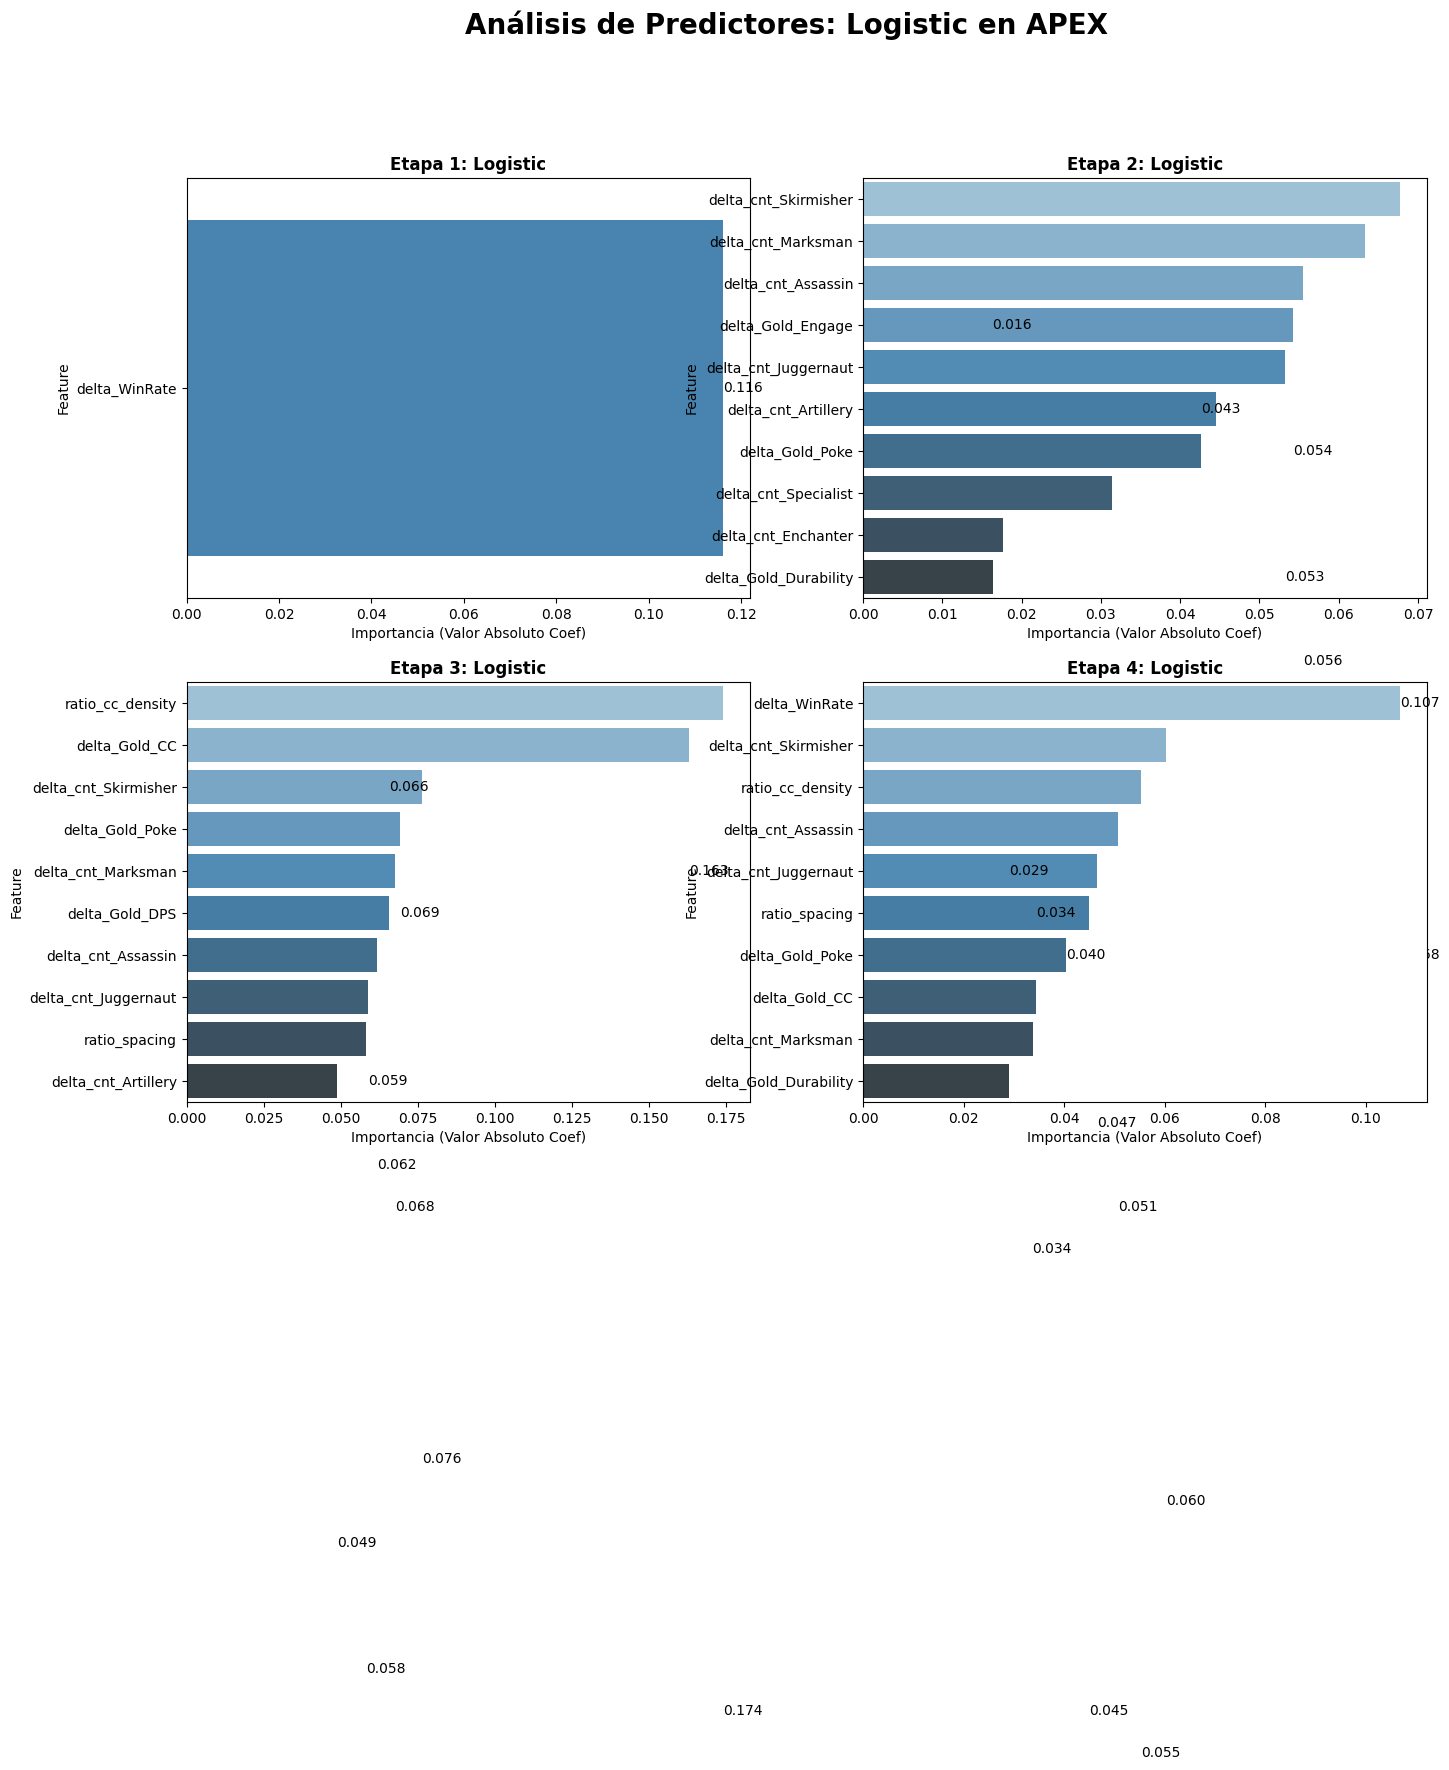

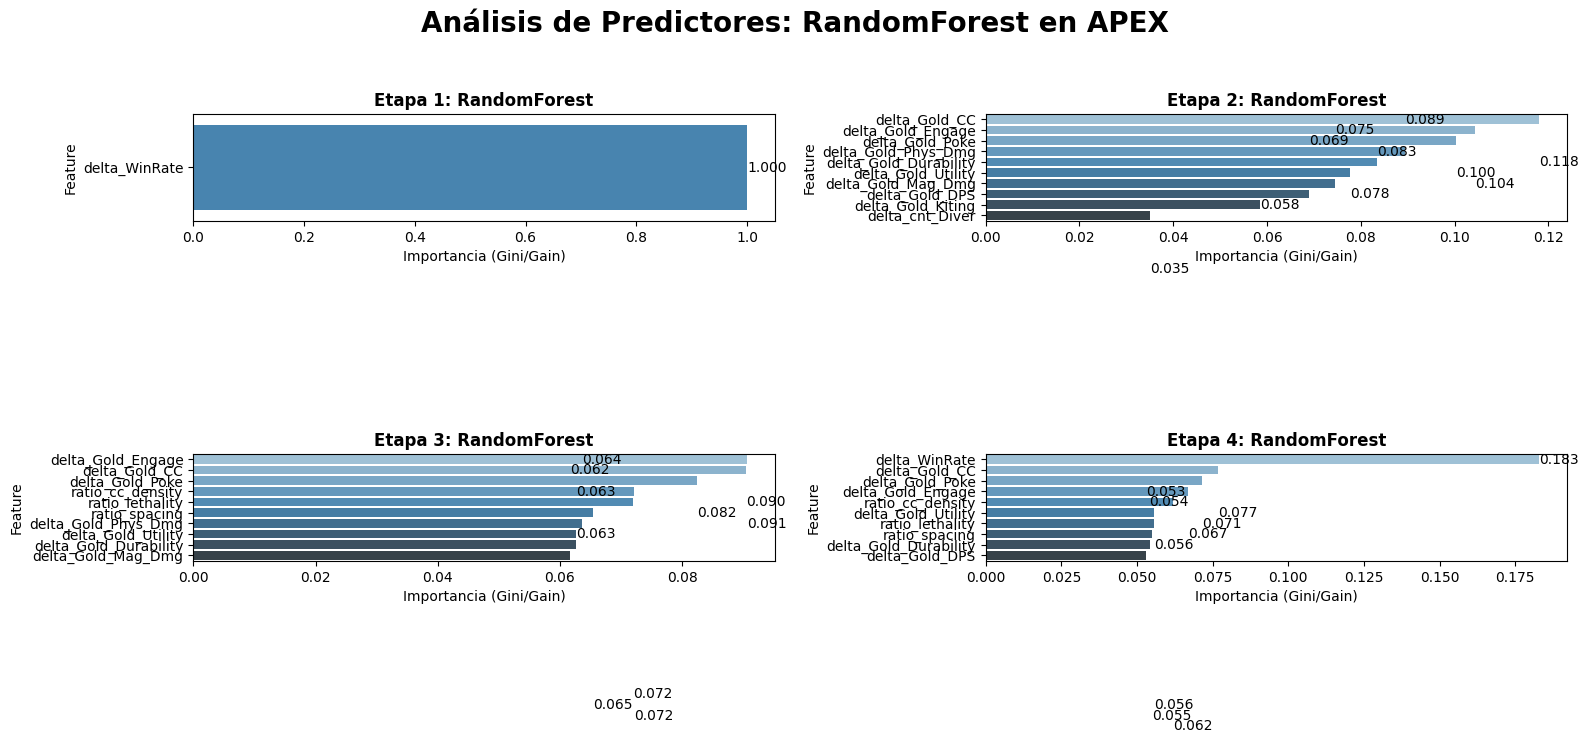

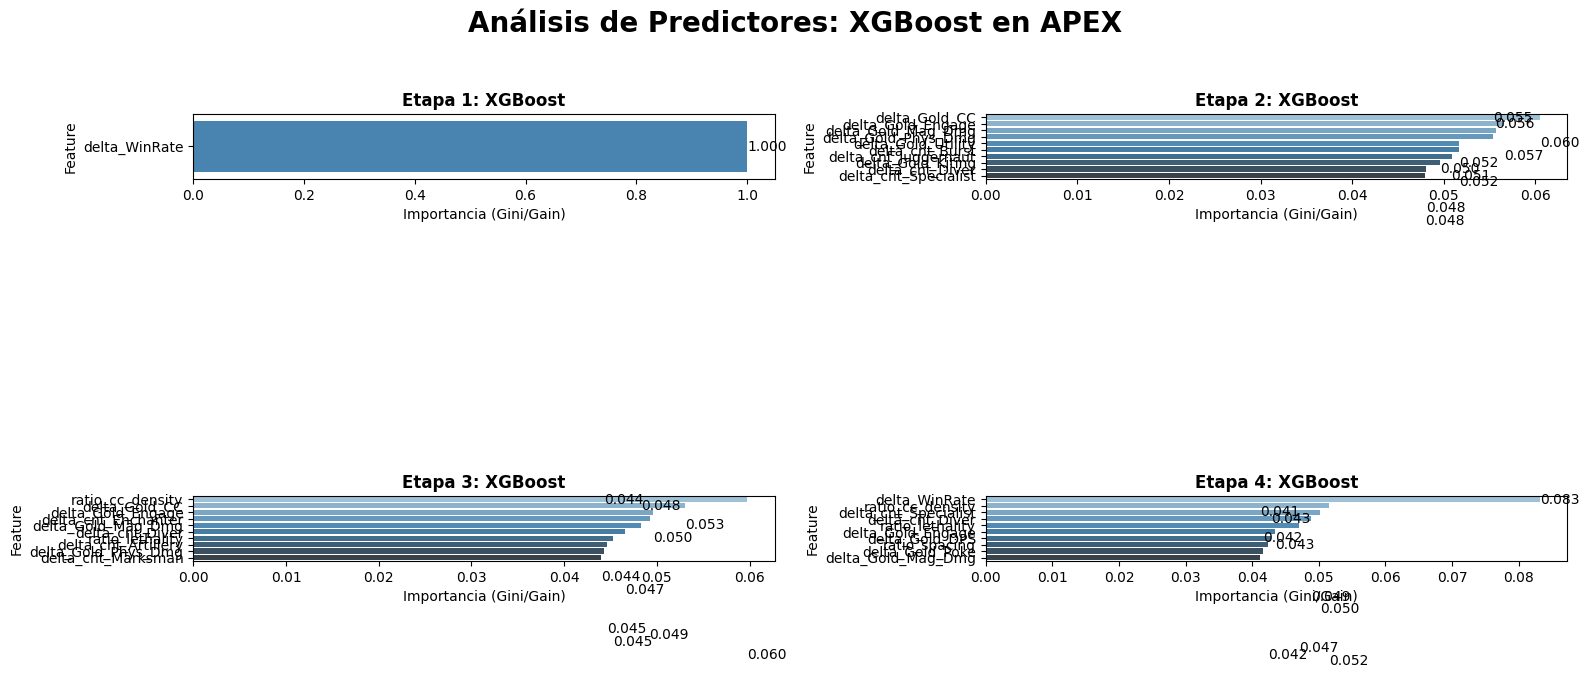

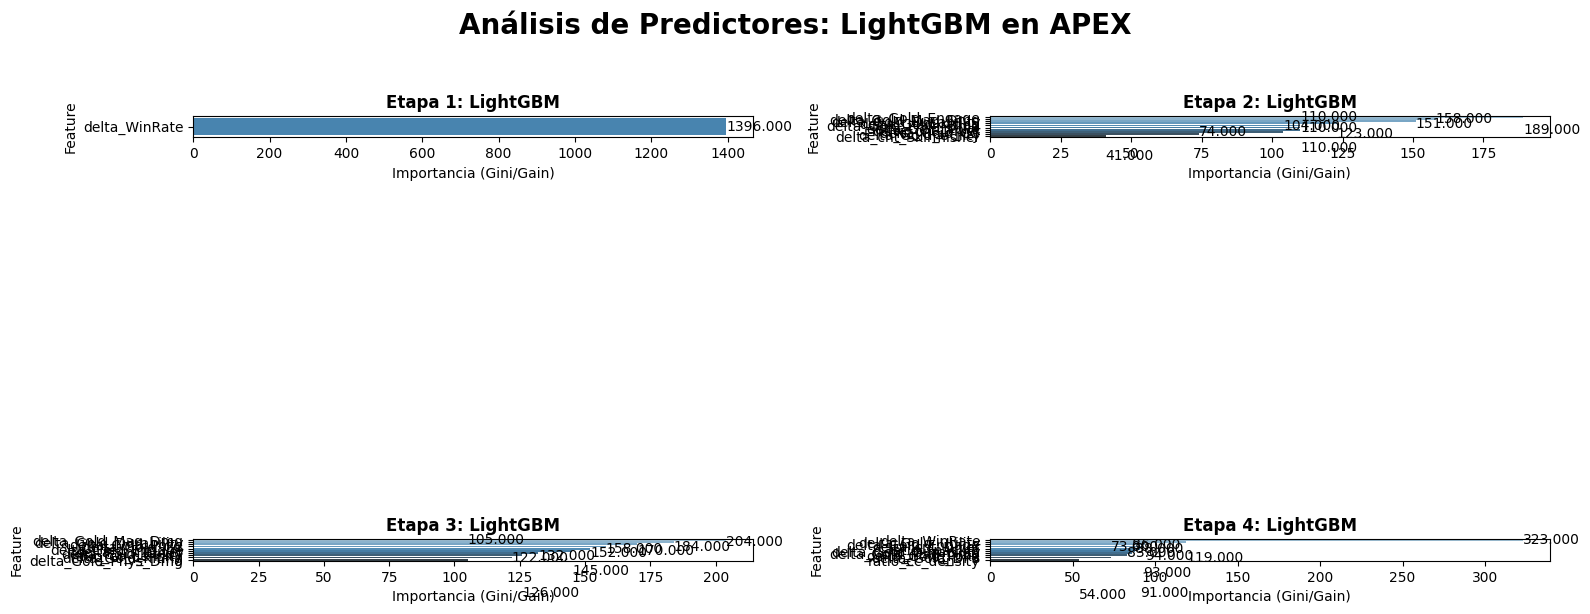

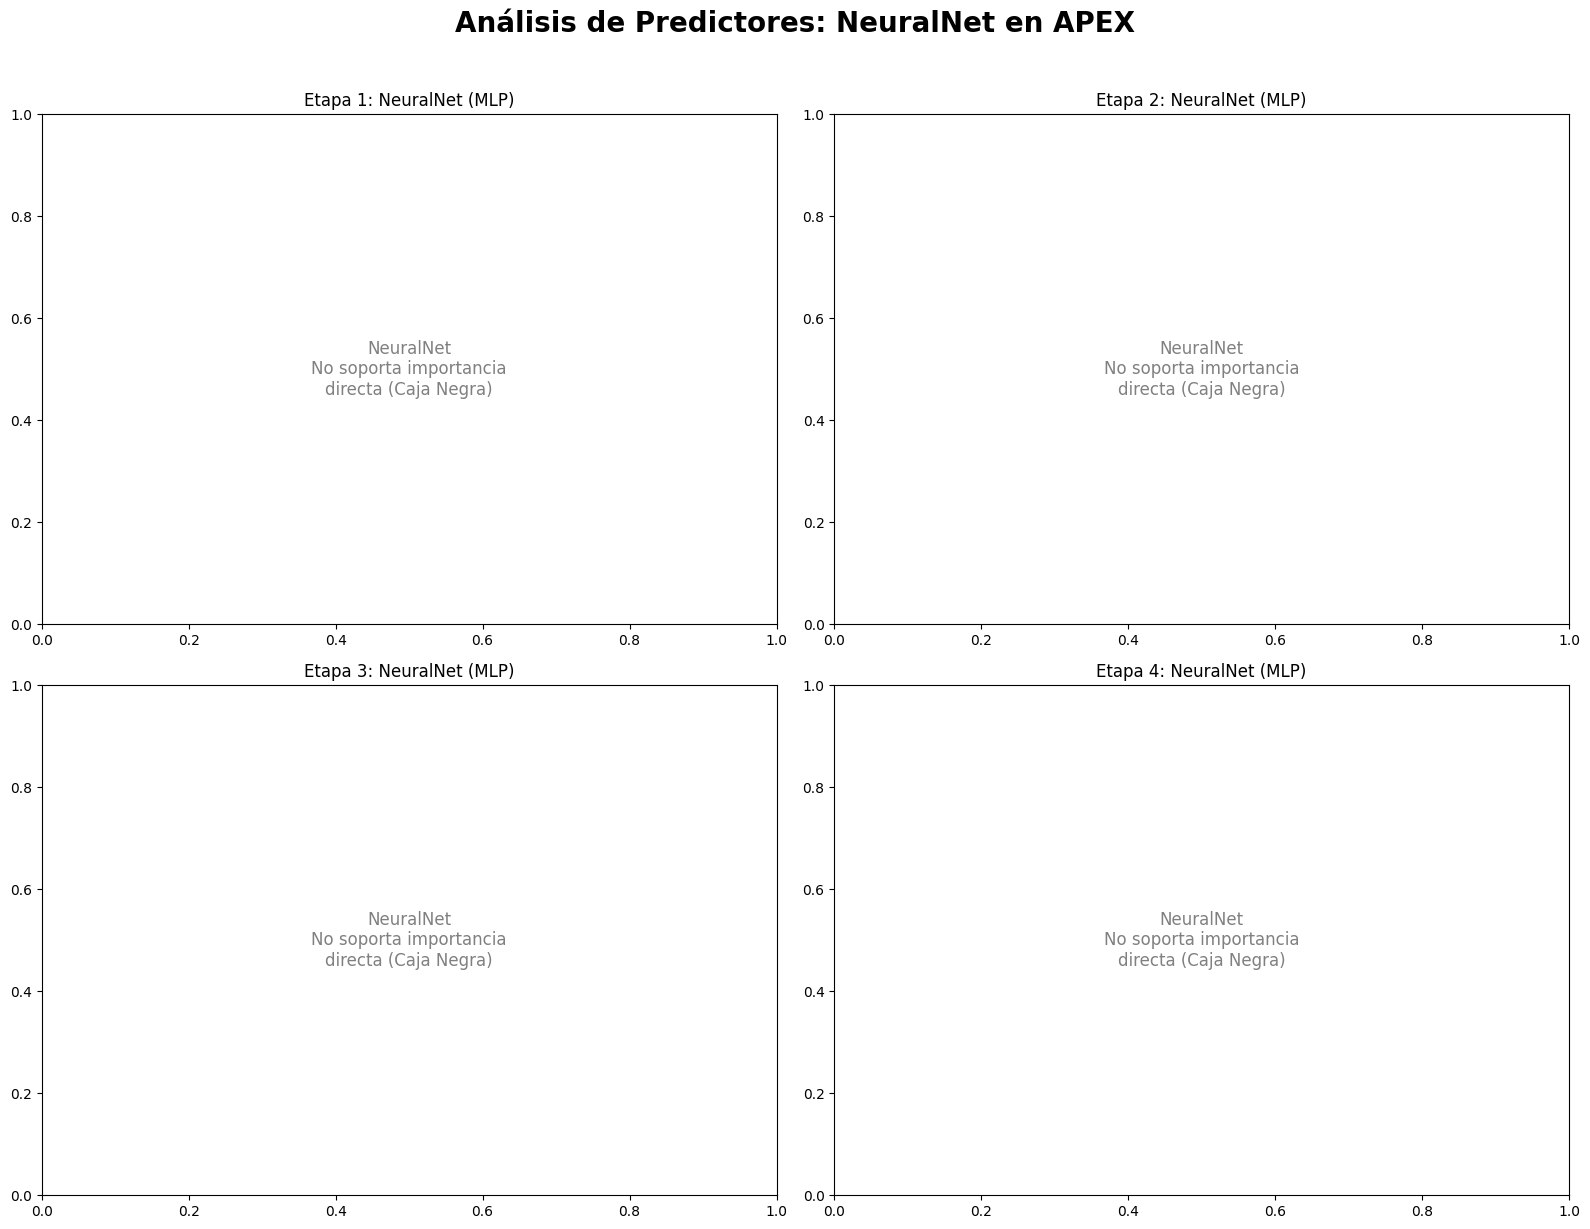

📊 Generando reportes para el Tier: LowTier...


/tmp/ipykernel_2354/3262023760.py:74: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


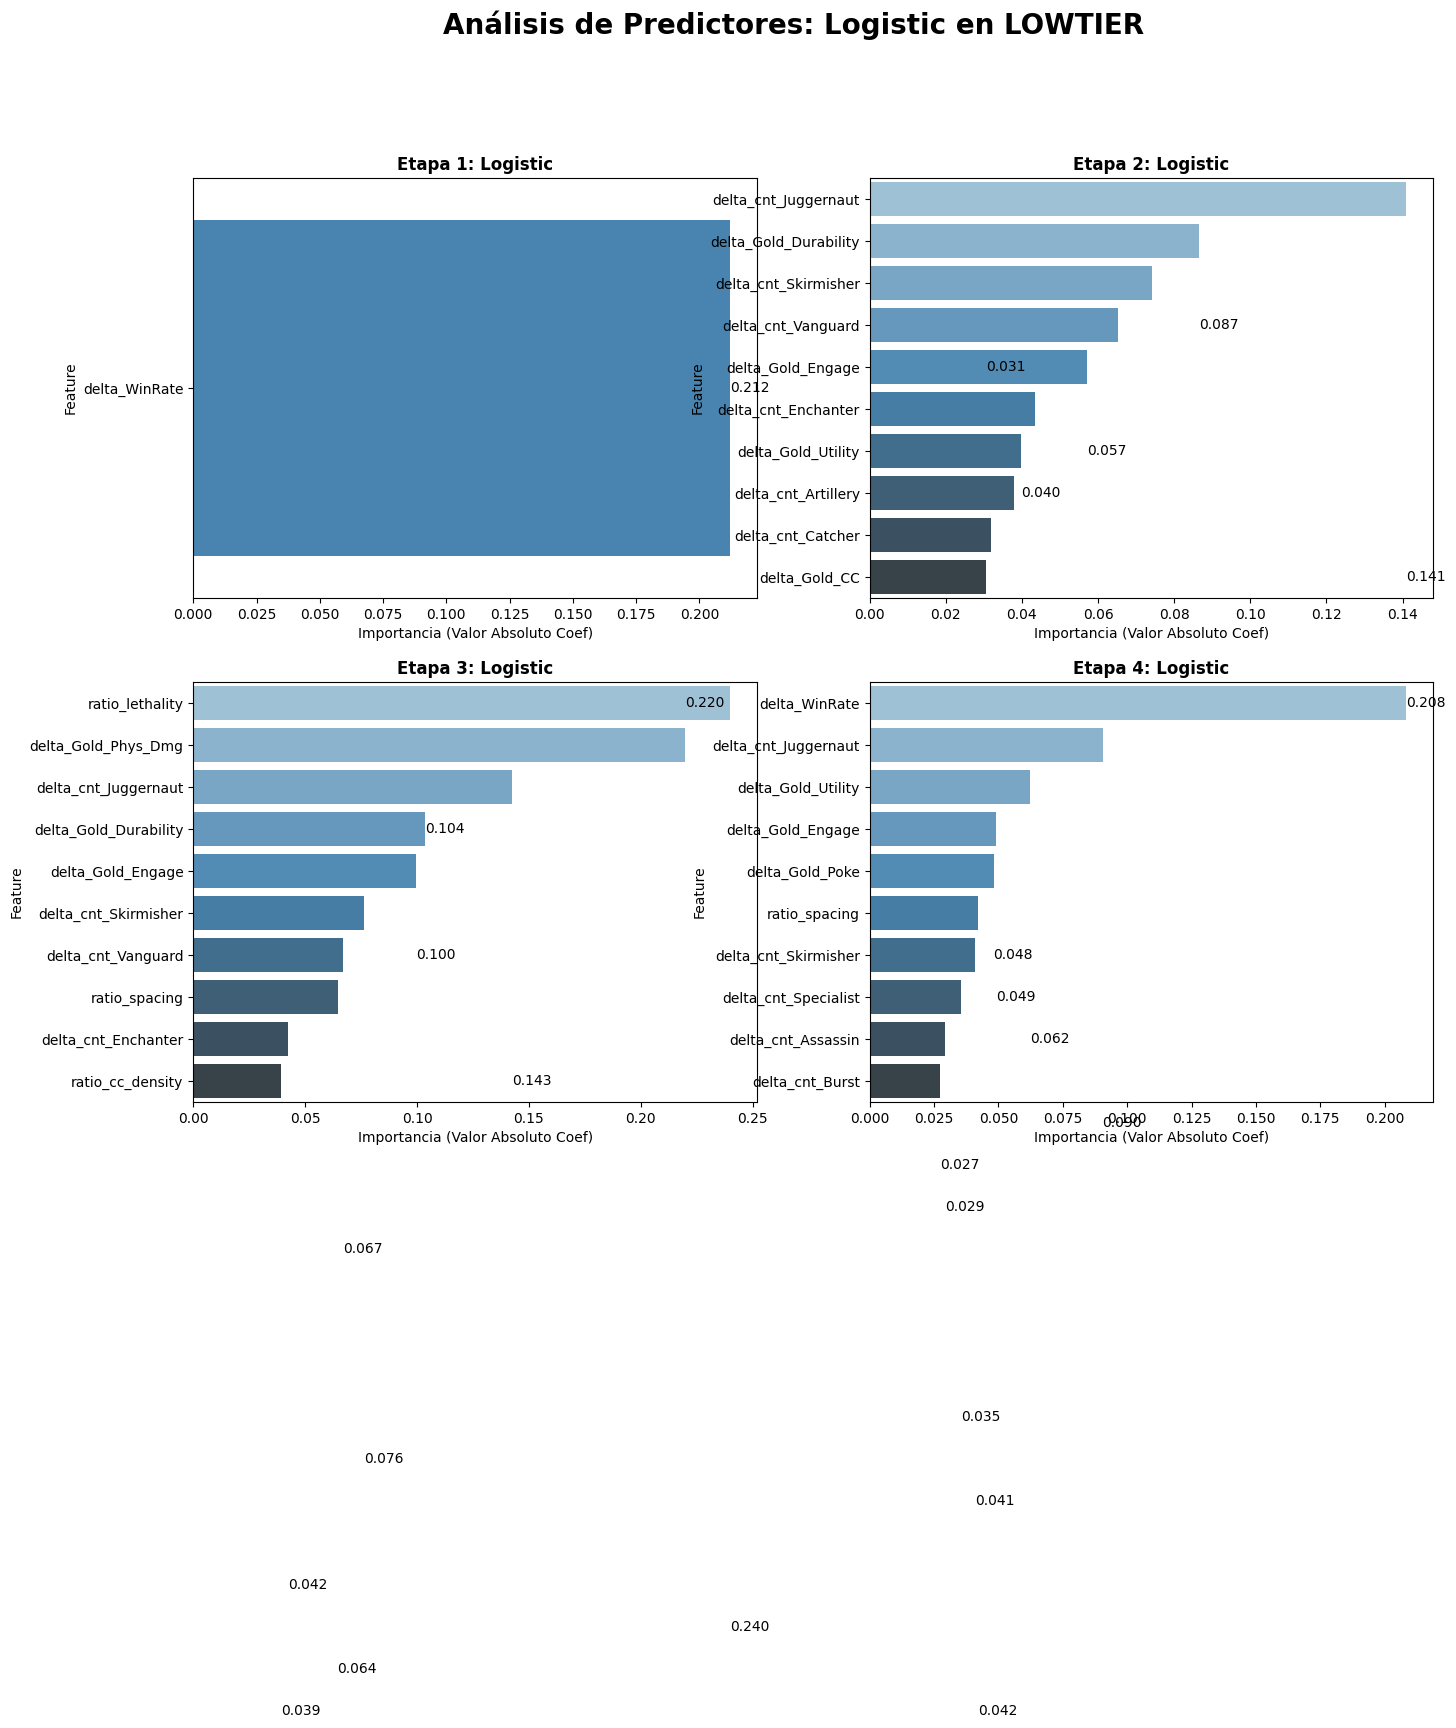

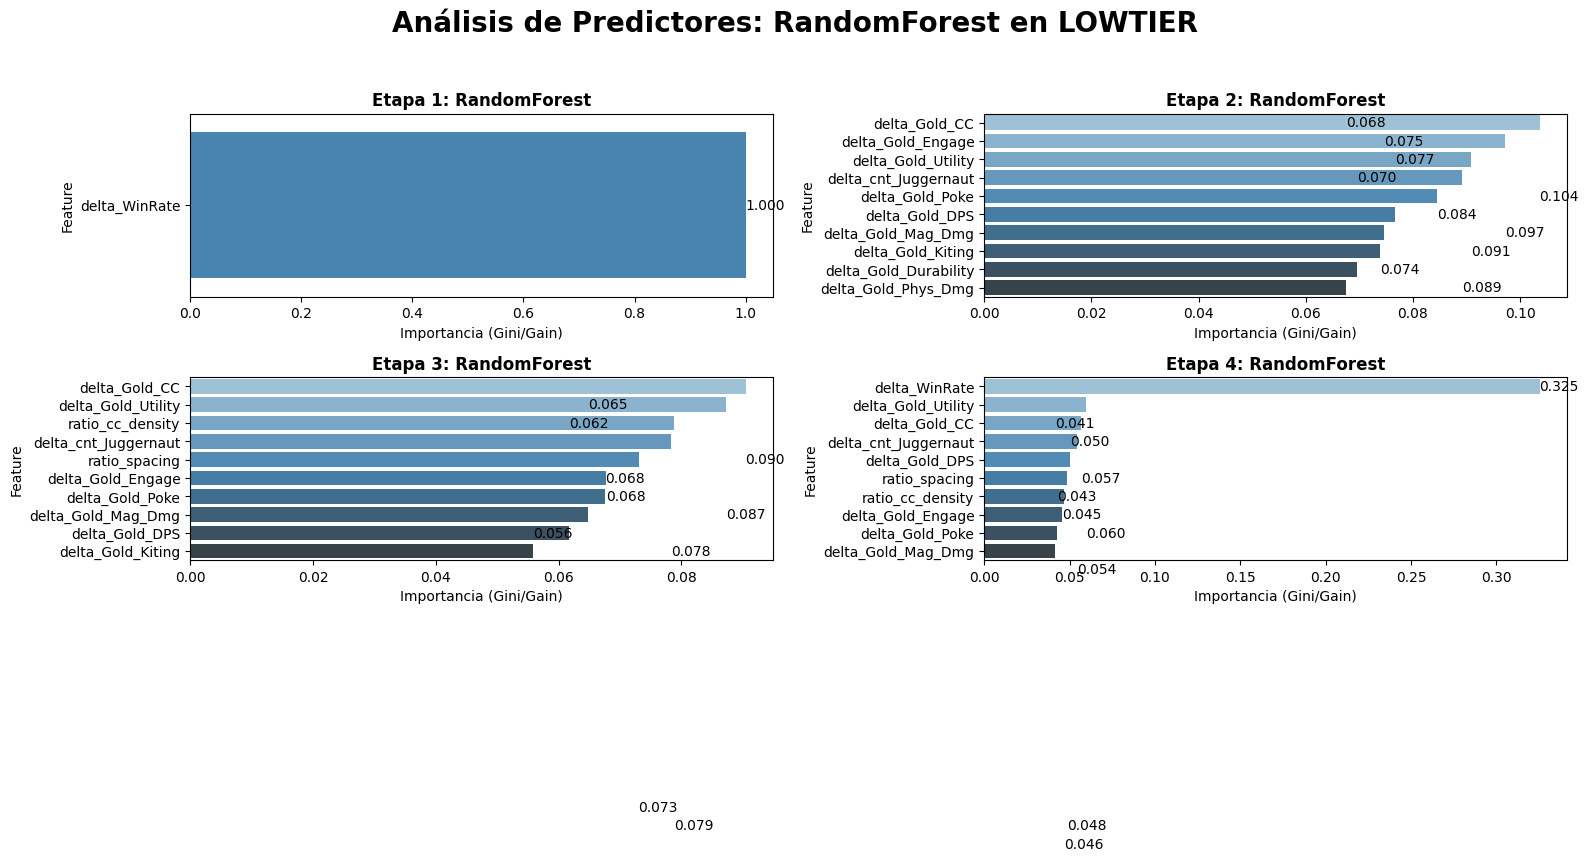

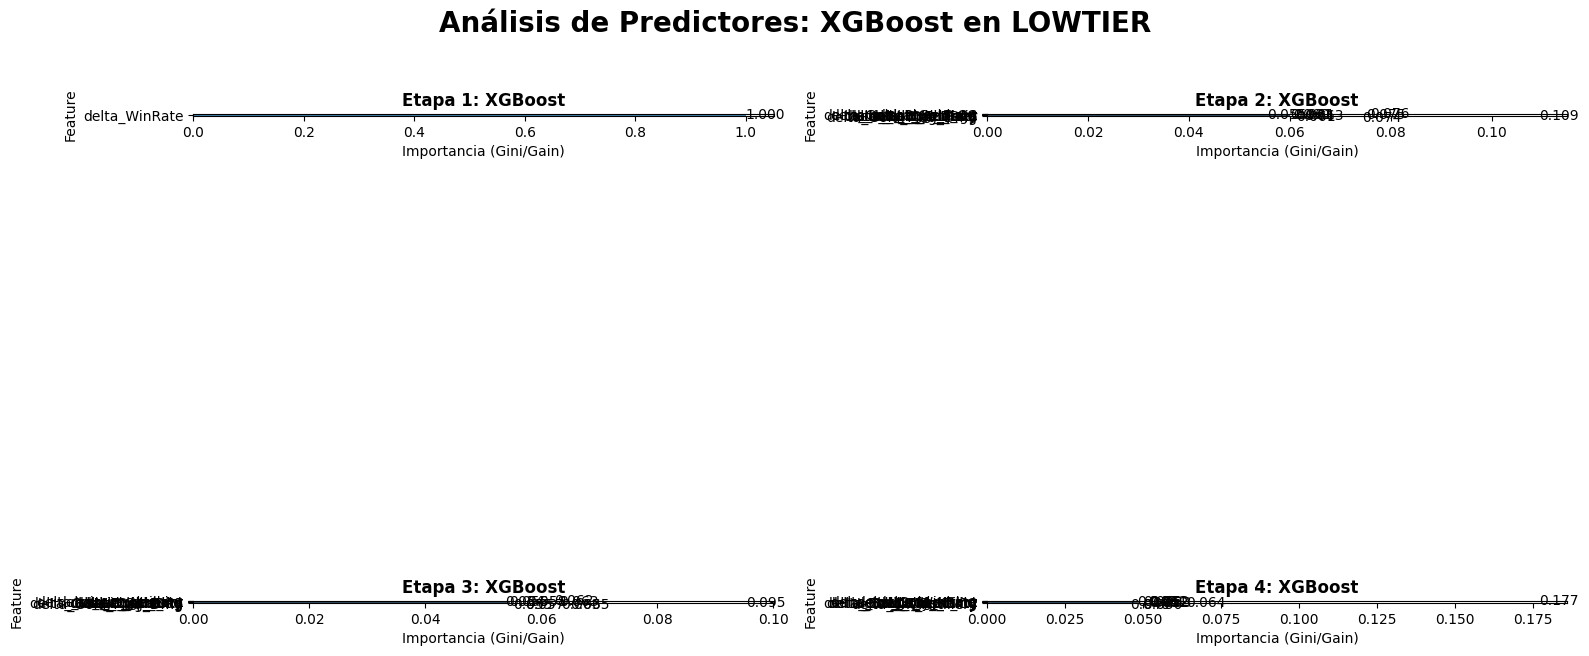

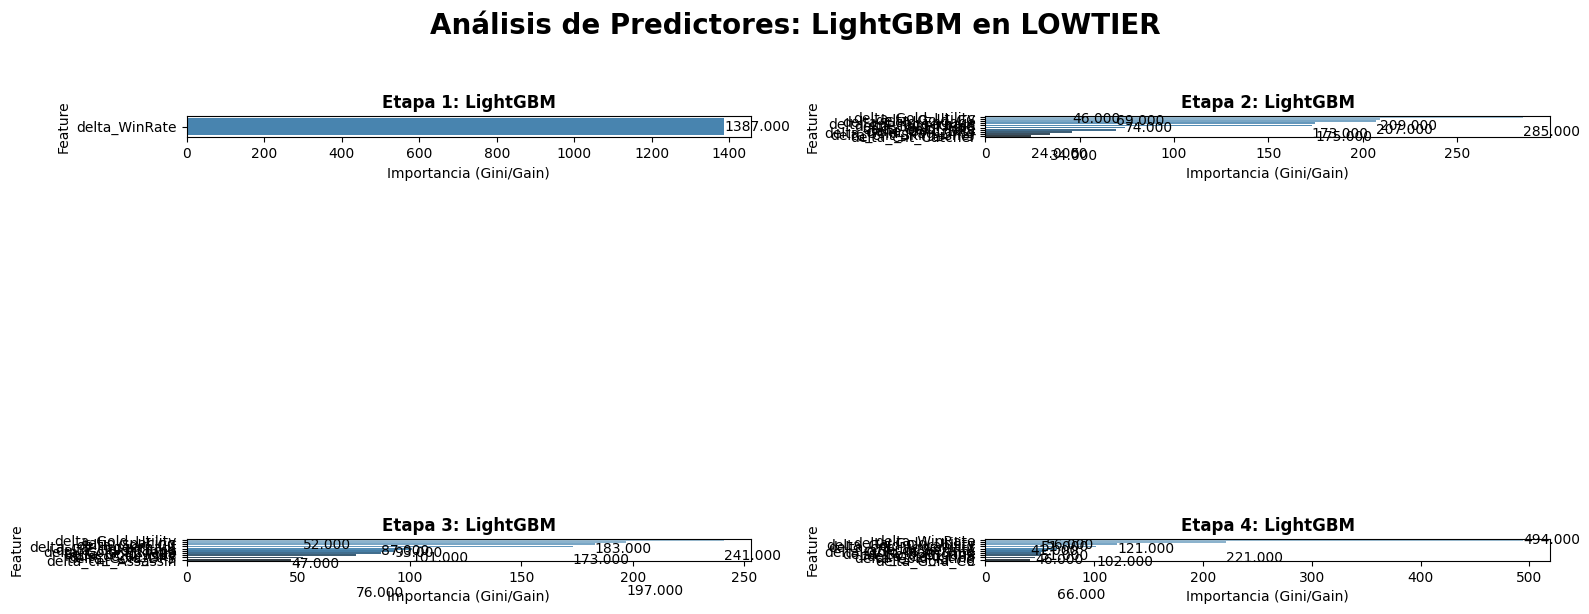

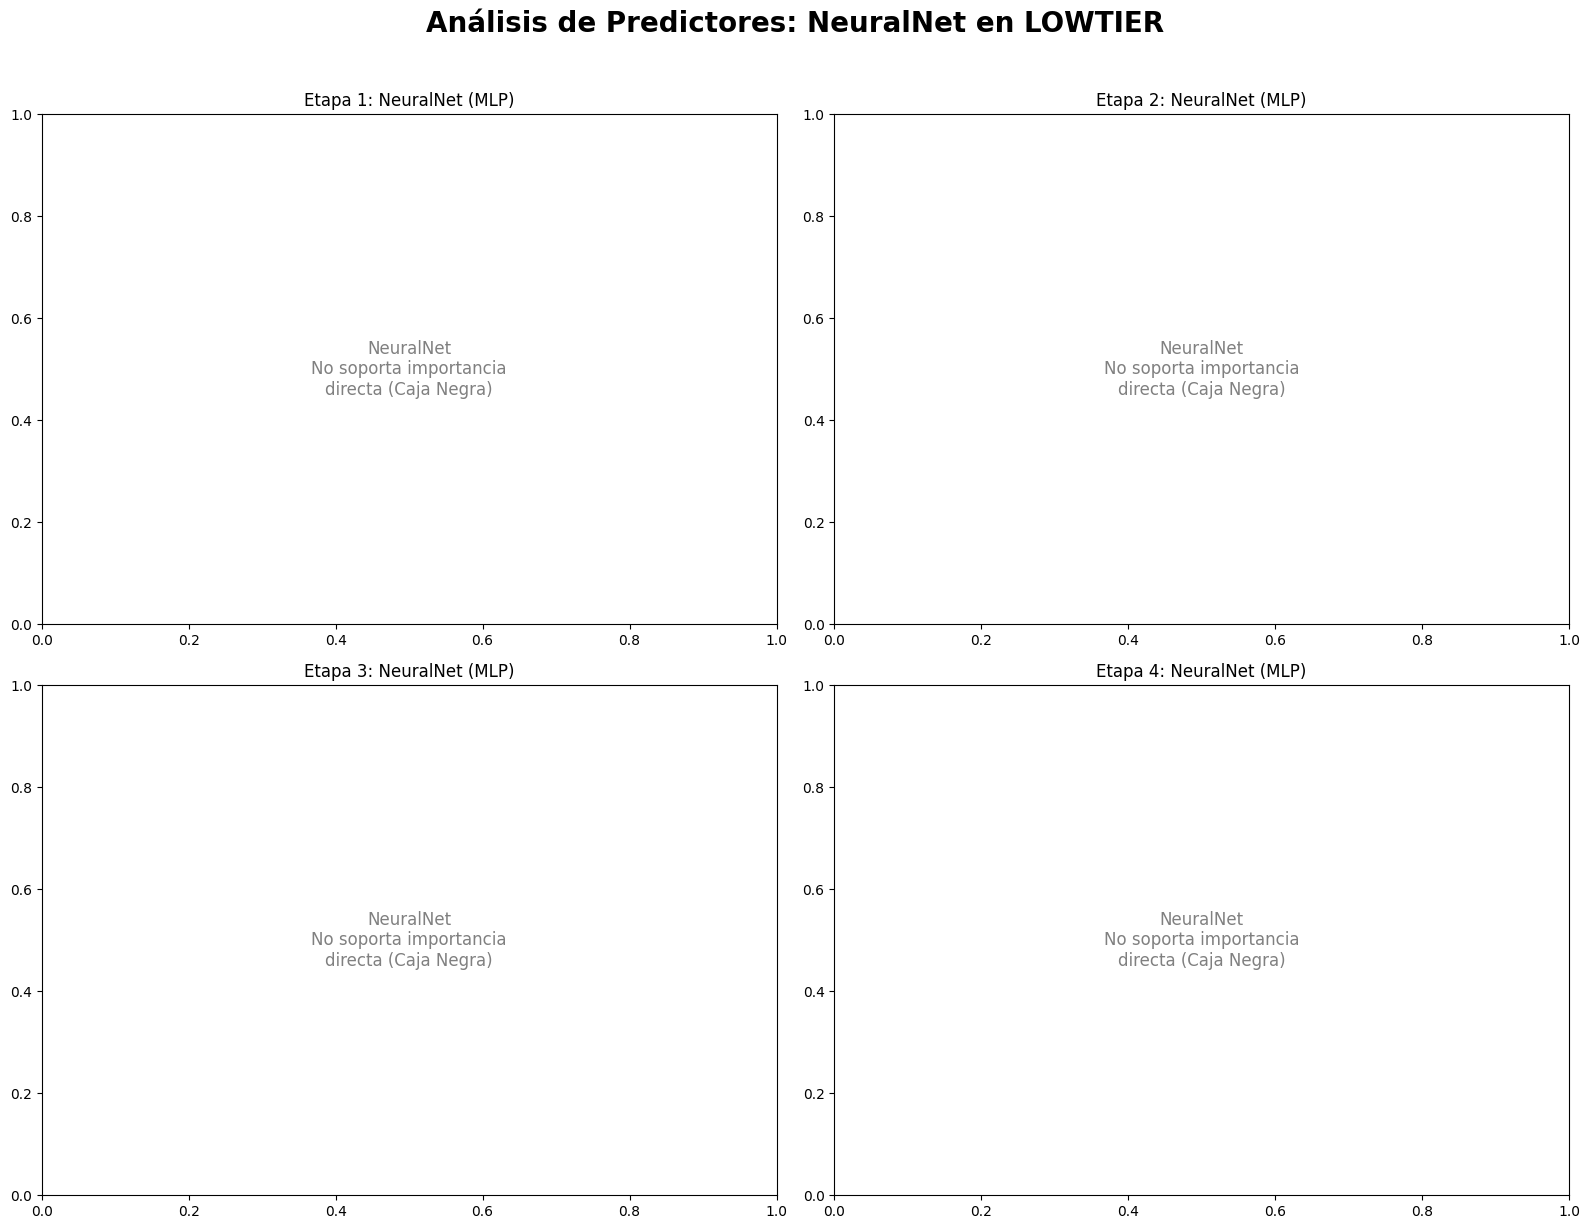

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_all_final_comparisons():
    # 1. Definir los nombres de los Tiers y los Modelos que entrenamos
    tier_names = ['Apex', 'LowTier']
    model_names = ['Logistic', 'RandomForest', 'XGBoost', 'LightGBM', 'NeuralNet']

    # 2. Mapa de características por etapa (Corrected to reflect get_stage_data output)
    # Ensure stats_cols, class_cols, and eng_cols are defined in an earlier cell.
    feat_map = {
        1: ['delta_WinRate'],
        2: stats_cols + class_cols,
        3: stats_cols + class_cols + eng_cols,
        4: ['delta_WinRate'] + stats_cols + class_cols + eng_cols
    }

    for tier in tier_names:
        print(f"📊 Generando reportes para el Tier: {tier}...")

        for m_name in model_names:
            # Crear la figura de 2x2 para las 4 etapas del modelo actual
            fig, axes = plt.subplots(2, 2, figsize=(16, 12))
            axes = axes.flatten()
            found_any_stage = False

            for i, stage in enumerate([1, 2, 3, 4]):
                key = f"{tier}_Stage{stage}_{m_name}"

                if key not in best_models_storage:
                    axes[i].set_title(f"Etapa {stage}: No entrenada", color='red')
                    continue

                found_any_stage = True
                trained_pipeline = best_models_storage[key]
                model_inside = trained_pipeline.named_steps['model']
                features = feat_map[stage]

                # Obtener importancia o coeficientes
                importance = None
                label_x = "Importancia (Gini/Gain)"

                if hasattr(model_inside, 'feature_importances_'):
                    importance = model_inside.feature_importances_
                elif hasattr(model_inside, 'coef_'):
                    importance = np.abs(model_inside.coef_[0])
                    label_x = "Importancia (Valor Absoluto Coef)"

                if importance is not None:
                    # Crear DataFrame y tomar Top 10
                    temp_df = pd.DataFrame({'Feature': features, 'Importance': importance})
                    temp_df = temp_df.sort_values(by='Importance', ascending=False).head(10)

                    # Fix for FutureWarning: Assign the `y` variable to `hue` and set `legend=False`
                    # Changed palette to 'Blues_d' for a blue theme
                    sns.barplot(data=temp_df, x='Importance', y='Feature', hue='Feature', ax=axes[i], palette='Blues_d', legend=False)

                    # Add text labels to the bars, now formatted to 3 decimal places
                    for index, row in temp_df.iterrows():
                        axes[i].text(row['Importance'], index, f"{row['Importance']:.3f}", va='center', ha='left', color='black')

                    axes[i].set_title(f"Etapa {stage}: {m_name}", fontweight='bold')
                    axes[i].set_xlabel(label_x)
                else:
                    axes[i].text(0.5, 0.5, f"{m_name}\nNo soporta importancia\ndirecta (Caja Negra)",
                                 ha='center', va='center', fontsize=12, color='gray')
                    axes[i].set_title(f"Etapa {stage}: {m_name} (MLP)")

            if found_any_stage:
                plt.suptitle(f'Análisis de Predictores: {m_name} en {tier.upper()}', fontsize=20, y=1.02, fontweight='black')
                plt.tight_layout()
                plt.show()
            else:
                plt.close() # Si no hay datos para este modelo, cerramos la figura vacía

# Ejecutar el generador masivo
plot_all_final_comparisons()

In [ ]:
import os
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# Crear un directorio para almacenar los gráficos de explicabilidad y no saturar la memoria
os.makedirs("graficos_shap", exist_ok=True)

# 1. Definición de las Grillas de Parámetros (Se mantienen idénticas)
param_grids = {
    'Logistic': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__penalty': ['l2']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, 15],
        'model__min_samples_split': [2, 5]
    },
    'XGBoost': {
        'model__n_estimators': [200, 300],
        'model__learning_rate': [0.01, 0.05],
        'model__max_depth': [3, 5]
    },
    'LightGBM': {
        'model__n_estimators': [200, 300],
        'model__learning_rate': [0.01, 0.05],
        'model__max_depth': [3, 5]
    }
    #, # NeuralNet commented out as per original notebook state
    #'NeuralNet': {
    #    'model__hidden_layer_sizes': [(64,), (64, 32)],
    #'model__alpha': [0.001, 0.01]
    #}
}

# 2. Diccionario de Modelos Base (Se mantienen idénticos)
base_models = {
    'Logistic': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(verbose=-1, random_state=42)
    #, # NeuralNet commented out as per original notebook state
    #'NeuralNet': MLPClassifier(max_iter=1000, random_state=42)
}

results_list = []

# --- NUEVO: Diccionario para guardar TODOS los modelos físicos entrenados ---
best_models_storage = {}

# Tracker para exportar el mejor modelo absoluto para Streamlit
best_trackers = {
    'Apex': {'auc': -1.0, 'artifact': None},
    'LowTier': {'auc': -1.0, 'artifact': None}
}

# Define feature names by stage (Corrected to reflect get_stage_data output)
# Ensure stats_cols, class_cols, and eng_cols are defined in an earlier cell.
feat_map = {
    1: ['delta_WinRate'],
    2: stats_cols + class_cols,
    3: stats_cols + class_cols + eng_cols,
    4: ['delta_WinRate'] + stats_cols + class_cols + eng_cols
}

for t_name, t_df in tiers:
    current_wr_map = wr_maps[t_name]
    train_raw, test_raw = train_test_split(t_df, test_size=0.2, random_state=42)

    for stage in range(1, 5):
        print(f"\n🚀 Iniciando Optimización y SHAP: {t_name} - Etapa {stage}")
        X_train, y_train = get_stage_data(train_raw, stage, current_wr_map)
        X_test, y_test = get_stage_data(test_raw, stage, current_wr_map)

        for m_name, model_obj in base_models.items():
            print(f"   🔎 Buscando mejor {m_name}...")

            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', model_obj)
            ])

            grid = GridSearchCV(
                pipe,
                param_grids[m_name],
                cv=3,
                scoring='roc_auc',
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            # Extracción del mejor estimador optimizado
            best_pipeline = grid.best_estimator_

            # --- NUEVO: Guardar el mejor modelo físico en best_models_storage ---
            model_key = f"{t_name}_Stage{stage}_{m_name}"
            best_models_storage[model_key] = best_pipeline

            p_class = best_pipeline.predict(X_test)
            p_prob = best_pipeline.predict_proba(X_test)[:, 1]

            current_test_auc = roc_auc_score(y_test, p_prob)

            results_list.append({
                'Tier': t_name,
                'Etapa': stage,
                'Modelo': m_name,
                'Best_Params': grid.best_params_,
                'CV_Mean_AUC': grid.best_score_,
                'Test_Acc': accuracy_score(y_test, p_class),
                'Test_AUC': current_test_auc,
                'Test_F1': f1_score(y_test, p_class)
            })

            # LÓGICA DE SELECCIÓN EXCLUSIVA PARA EL DESPLIEGUE
            # Si el modelo actual supera el rendimiento histórico en Test del Tier, actualizamos el artefacto
            if current_test_auc > best_trackers[t_name]['auc']:
                best_trackers[t_name]['auc'] = current_test_auc
                best_trackers[t_name]['artifact'] = {
                    'pipeline': best_pipeline,                  # Incluye el objeto StandardScaler y el Modelo optimizados
                    'stage': stage,                          # Almacena qué etapa (1, 2, 3 o 4) generó el éxito
                    'model_type': m_name,                    # Nombre del algoritmo (ej. LightGBM)
                    'feature_names': feat_map[stage]   # Mapeo estricto del orden de las variables requeridas
                }

            # =========================================================================
            # 📊 EJECUCIÓN DEL ANÁLISIS SHAP CON TOLERANCIA A FALLOS Y ADAPTACIÓN DE MODELO
            # =========================================================================
            print(f"      🧬 Calculando SHAP para {m_name} (Etapa {stage})...")

            # 1. Aislar componentes del Pipeline para procesar correctamente las dimensiones
            scaler_entrenado = best_pipeline.named_steps['scaler']
            modelo_matematico = best_pipeline.named_steps['model']

            # 2. Transformar el set de test usando el StandardScaler del pliegue correspondiente
            X_test_scaled_df = pd.DataFrame(scaler_entrenado.transform(X_test), columns=feat_map[stage])

            try:
                # Tratamiento especial para Redes Neuronales (MLP) para evitar congelamiento de CPU
                # Note: NeuralNet is currently commented out in base_models, so this block won't execute unless uncommented.
                if m_name == 'NeuralNet':
                    # Submuestreo drástico: 30 filas de fondo y 20 filas para evaluar el impacto marginal
                    background_data = shap.sample(X_test_scaled_df, 30, random_state=42)
                    eval_data = shap.sample(X_test_scaled_df, 20, random_state=42)

                    explainer = shap.KernelExplainer(modelo_matematico.predict_proba, background_data)
                    shap_values = explainer(eval_data)
                else:
                    # El explicador polimórfico resuelve automáticamente TreeExplainer o LinearExplainer
                    explainer = shap.Explainer(modelo_matematico, X_test_scaled_df)
                    shap_values = explainer(X_test_scaled_df)

                # Generación y almacenamiento del gráfico Beeswarm (Distribución de impacto)
                plt.figure(figsize=(10, 6))
                # Ajuste para manejar la indexación de SHAP en salidas probabilísticas si aplica
                if hasattr(shap_values, "output_names") and shap_values.values.ndim == 3:
                    # Seleccionar la clase 1 (probabilidad de victoria) si el output es tridimensional
                    shap.plots.beeswarm(shap_values[:, :, 1], max_display=12, show=False)
                else:
                    shap.plots.beeswarm(shap_values, max_display=12, show=False)

                plt.title(f"SHAP Beeswarm: {t_name} | {m_name} | Etapa {stage}", fontsize=12, fontweight='bold')
                plt.tight_layout()

                # Guardado físico en disco para el documento de resultados
                path_guardado = f"graficos_shap/shap_{t_name.lower()}_stage{stage}_{m_name.lower()}.png"
                plt.savefig(path_guardado, dpi=150)
                plt.close() # Libera la memoria de la figura actual de inmediato

            except Exception as e:
                print(f"      ⚠️ No se pudo procesar SHAP para {m_name} en esta configuración. Error: {str(e)}")
                plt.close()

# Guardado final de artefactos .joblib para el backend de Streamlit
for t_name, tracker in best_trackers.items():
    if tracker['artifact'] is not None:
        joblib.dump(tracker['artifact'], f'best_model_{t_name.lower()}.joblib')

df_grid_results = pd.DataFrame(results_list)
print("\n✅ ¡Flujo completo finalizado! Modelos guardados y gráficos SHAP exportados a la carpeta 'graficos_shap/'.")


🚀 Iniciando Optimización y SHAP: Apex - Etapa 1
   🔎 Buscando mejor Logistic...
      🧬 Calculando SHAP para Logistic (Etapa 1)...
   🔎 Buscando mejor RandomForest...
      🧬 Calculando SHAP para RandomForest (Etapa 1)...


 99%|===================| 10678/10840 [00:24<00:00]       

   🔎 Buscando mejor XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:46:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


      🧬 Calculando SHAP para XGBoost (Etapa 1)...


...

   🔎 Buscando mejor LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


      🧬 Calculando SHAP para LightGBM (Etapa 4)...


 96%|=================== | 5208/5420 [00:17<00:00]       

      ⚠️ No se pudo procesar SHAP para LightGBM en esta configuración. Error: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. This check failed because for one of the samples the sum of the SHAP values was 0.174614, while the model output was 0.298937. If this difference is acceptable you can set check_additivity=False to disable this check.

✅ ¡Flujo completo finalizado! Modelos guardados y gráficos SHAP exportados a la carpeta 'graficos_shap/'.
